# ML Experiment Results Analysis & Visualization
## Invoice Payment Prediction — April 2026 Corrected Re-run

**Source DB:** `results/2026_04_18_02/results.db`  
**Experiments:** 1092 total (15 models × 7 balance strategies × ~10 param sets × 2 feature phases)  
**Primary metrics:** `enhanced_f1_macro`, `enhanced_roc_auc_macro`  
**Output figures:** `docs/202616APRIL-RESULTSGRAPHS/`

---
All four pipeline bugs (resample accumulation, Cox leakage, pickling, nested parallelism) were fixed before this run. Schema v3 — `undersample_threshold` fully populated for all hybrid rows.

In [2]:
import sqlite3
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
DB_PATH    = "results/2026_04_18_02/results.db"
OUTPUT_DIR = Path("docs/202616APRIL-RESULTSGRAPHS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

# ── Model metadata ────────────────────────────────────────────────────────────
BASE_MODELS    = ["ada_boost", "decision_tree", "gaussian_naive_bayes",
                  "knn", "random_forest", "xgboost"]
ORDINAL_MODELS = ["ordinal_ada_boost", "ordinal_random_forest", "ordinal_xgboost"]
TWO_STAGE_MODELS = ["two_stage_ada_xgb", "two_stage_rf_ada", "two_stage_rf_rf",
                    "two_stage_xgb_ada", "two_stage_xgb_rf", "two_stage_xgb_xgb"]
ALL_MODELS = BASE_MODELS + ORDINAL_MODELS + TWO_STAGE_MODELS

MODEL_DISPLAY = {
    "ada_boost":            "AdaBoost",
    "decision_tree":        "Decision Tree",
    "gaussian_naive_bayes": "Gaussian NB",
    "knn":                  "KNN",
    "random_forest":        "Random Forest",
    "xgboost":              "XGBoost",
    "ordinal_ada_boost":    "Ordinal AdaBoost",
    "ordinal_random_forest":"Ordinal RF",
    "ordinal_xgboost":      "Ordinal XGBoost",
    "two_stage_ada_xgb":    "TS Ada→XGB",
    "two_stage_rf_ada":     "TS RF→Ada",
    "two_stage_rf_rf":      "TS RF→RF",
    "two_stage_xgb_ada":    "TS XGB→Ada",
    "two_stage_xgb_rf":     "TS XGB→RF",
    "two_stage_xgb_xgb":    "TS XGB→XGB",
}

FAMILY_MAP = {}
FAMILY_MAP.update({m: "Base"      for m in BASE_MODELS})
FAMILY_MAP.update({m: "Ordinal"   for m in ORDINAL_MODELS})
FAMILY_MAP.update({m: "Two-Stage" for m in TWO_STAGE_MODELS})

# Which base model each ordinal/two-stage variant extends
ORDINAL_BASE_MAP = {
    "ordinal_ada_boost":    "ada_boost",
    "ordinal_random_forest":"random_forest",
    "ordinal_xgboost":      "xgboost",
}
TWO_STAGE_BASE_MAP = {
    "two_stage_ada_xgb": "xgboost",
    "two_stage_rf_ada":  "ada_boost",
    "two_stage_rf_rf":   "random_forest",
    "two_stage_xgb_ada": "ada_boost",
    "two_stage_xgb_rf":  "random_forest",
    "two_stage_xgb_xgb": "xgboost",
}

STRATEGY_ORDER = ["none", "smote", "borderline_smote", "smote_tomek",
                  "hybrid@0.5", "hybrid@0.7", "hybrid@0.9"]
STRATEGY_LABELS = {
    "none":             "None",
    "smote":            "SMOTE",
    "borderline_smote": "Borderline SMOTE",
    "smote_tomek":      "SMOTE+Tomek",
    "hybrid@0.5":       "Hybrid @0.5",
    "hybrid@0.7":       "Hybrid @0.7",
    "hybrid@0.9":       "Hybrid @0.9",
}

CLASS_NAMES = ["On-Time (0)", "30-Day (1)", "60-Day (2)", "90-Day (3)"]

FAMILY_PALETTE = {"Base": "#4878CF", "Ordinal": "#6ACC65", "Two-Stage": "#D65F5F"}
STRATEGY_PALETTE = dict(zip(STRATEGY_ORDER, sns.color_palette("tab10", 7)))

print("✓ Configuration loaded")
print(f"  DB       : {DB_PATH}")
print(f"  Output   : {OUTPUT_DIR.resolve()}")

✓ Configuration loaded
  DB       : results/2026_04_18_02/results.db
  Output   : D:\Developer\Projects\THESIS-Utilizing-ML-to-Solve-the-IPPP\docs\202616APRIL-RESULTSGRAPHS


## Section 1 — Load Results Database

In [3]:
conn = sqlite3.connect(DB_PATH)

# ── Raw tables ────────────────────────────────────────────────────────────────
exp_df  = pd.read_sql("SELECT * FROM experiments",    conn)
met_df  = pd.read_sql("SELECT * FROM metrics",        conn)
feat_df = pd.read_sql("SELECT * FROM features",       conn)

class_mappings  = json.loads(pd.read_sql("SELECT data FROM class_mappings",  conn).iloc[0, 0])
survival_data   = json.loads(pd.read_sql("SELECT data FROM survival_results",conn).iloc[0, 0])
metadata        = json.loads(pd.read_sql("SELECT data FROM metadata",        conn).iloc[0, 0])

# ── Pivot metrics: 2 rows per experiment → wide format ───────────────────────
# Column name convention: {phase}_{metric}  e.g. enhanced_f1_macro, baseline_accuracy
met_wide = met_df.pivot_table(
    index   = "experiment_id",
    columns = "phase",
    values  = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"],
    aggfunc = "first",
)
met_wide.columns = [f"{phase}_{metric}" for metric, phase in met_wide.columns]
met_wide = met_wide.reset_index()

# ── Join ──────────────────────────────────────────────────────────────────────
df = exp_df.merge(met_wide, left_on="id", right_on="experiment_id", how="left")

# Derived columns
def _strategy_label(row):
    if row["balance_strategy"] == "hybrid" and pd.notna(row["undersample_threshold"]):
        return f"hybrid@{row['undersample_threshold']:.1f}"
    return row["balance_strategy"]

df["strategy_label"] = df.apply(_strategy_label, axis=1)
df["model_display"]  = df["model"].map(MODEL_DISPLAY)
df["family"]         = df["model"].map(FAMILY_MAP)
df["f1_lift"]        = df["enhanced_f1_macro"] - df["baseline_f1_macro"]

print(f"✓  Loaded {len(df):,} experiments, {len(met_df):,} metric rows")
print(f"   Metric columns: {[c for c in df.columns if 'f1' in c or 'auc' in c]}")
print(f"\n   Metadata :")
print(f"     Run start  : {metadata.get('training_start_time','?')}")
print(f"     Run end    : {metadata.get('training_end_time','?')}")
print(f"     Duration   : {metadata.get('training_run_time','?')}")
print(f"\n   CoxPH survival results :")
print(f"     C-index    : {survival_data.get('best_c_index', '?')}")
print(f"     Best params: {survival_data.get('best_params', '?')}")

✓  Loaded 1,092 experiments, 2,184 metric rows
   Metric columns: ['baseline_f1_macro', 'enhanced_f1_macro', 'baseline_roc_auc_macro', 'enhanced_roc_auc_macro', 'f1_lift']

   Metadata :
     Run start  : 2026-04-18T20:01:50
     Run end    : 2026-04-18T23:29:21
     Duration   : 3h 27m 31s

   CoxPH survival results :
     C-index    : 0.7817
     Best params: ?


## Section 2 — Data Quality Check

In [4]:
issues = []

# ── NaN check on primary metrics ─────────────────────────────────────────────
for col in ["enhanced_f1_macro", "enhanced_roc_auc_macro",
            "baseline_f1_macro", "baseline_roc_auc_macro"]:
    n_null = df[col].isna().sum()
    status = "✓" if n_null == 0 else f"⚠ {n_null} NULLs"
    print(f"  {col:<35} {status}")
    if n_null:
        issues.append(f"NaN in {col}: {n_null} rows")

# ── Row counts per balance strategy ──────────────────────────────────────────
print("\n--- Experiments per balance_strategy ---")
strat_counts = df.groupby("strategy_label").size().reindex(STRATEGY_ORDER, fill_value=0)
for s, cnt in strat_counts.items():
    ok = "✓" if cnt == 156 else f"⚠ expected 156, got {cnt}"
    print(f"  {s:<22} {cnt:>4}   {ok}")
    if cnt != 156:
        issues.append(f"Strategy {s}: count={cnt} (expected 156)")

# ── Row counts per model ──────────────────────────────────────────────────────
print("\n--- Experiments per model type (expected 72 each = 7 strategies × ~10 param sets) ---")
model_counts = df.groupby("model").size().reindex(ALL_MODELS, fill_value=0)
for m, cnt in model_counts.items():
    flag = "" if cnt > 0 else "  ⚠ ZERO rows"
    print(f"  {MODEL_DISPLAY.get(m, m):<25} {cnt:>4}{flag}")
    if cnt == 0:
        issues.append(f"Model {m}: ZERO rows")

# ── Hybrid NULL check ─────────────────────────────────────────────────────────
hybrid_nulls = df[df["balance_strategy"] == "hybrid"]["undersample_threshold"].isna().sum()
print(f"\n--- Hybrid undersample_threshold NULLs: {hybrid_nulls} ---")
if hybrid_nulls == 0:
    print("  ✓ All hybrid rows have threshold populated")
else:
    print(f"  ⚠ {hybrid_nulls} hybrid rows have NULL threshold — re-run required")
    issues.append(f"Hybrid threshold NULL: {hybrid_nulls}")

# ── Enhanced vs baseline lift check ──────────────────────────────────────────
df["f1_lift"] = df["enhanced_f1_macro"] - df["baseline_f1_macro"]
mean_lift = df["f1_lift"].mean()
neg_lift = (df["f1_lift"] < -0.02).sum()
print(f"\n--- Enhanced vs Baseline F1 lift ---")
print(f"  Mean lift  : {mean_lift:+.4f}")
print(f"  Rows with large negative lift (< −0.02): {neg_lift}")
if neg_lift > 50:
    issues.append(f"Many rows with negative F1 lift: {neg_lift}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
if issues:
    print(f"⚠  {len(issues)} quality issues found:")
    for iss in issues:
        print(f"   · {iss}")
else:
    print("✓  All quality checks passed — data is clean")

  enhanced_f1_macro                   ✓
  enhanced_roc_auc_macro              ✓
  baseline_f1_macro                   ✓
  baseline_roc_auc_macro              ✓

--- Experiments per balance_strategy ---
  none                    156   ✓
  smote                   156   ✓
  borderline_smote        156   ✓
  smote_tomek             156   ✓
  hybrid@0.5              156   ✓
  hybrid@0.7              156   ✓
  hybrid@0.9              156   ✓

--- Experiments per model type (expected 72 each = 7 strategies × ~10 param sets) ---
  AdaBoost                    49
  Decision Tree               42
  Gaussian NB                 56
  KNN                         42
  Random Forest              119
  XGBoost                     77
  Ordinal AdaBoost            49
  Ordinal RF                 119
  Ordinal XGBoost             77
  TS Ada→XGB                  70
  TS RF→Ada                   70
  TS RF→RF                    84
  TS XGB→Ada                  70
  TS XGB→RF                   84
  TS XGB→XG

## Section 3 — Model Rankings by Primary Metrics

In [5]:
DISPLAY_COLS = {
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Balance Strategy",
    "enhanced_f1_macro":      "F1 (enhanced)",
    "enhanced_roc_auc_macro": "AUC (enhanced)",
    "baseline_f1_macro":      "F1 (baseline)",
    "baseline_roc_auc_macro": "AUC (baseline)",
    "param_hash":             "Params",
}

# ── Top-20 by enhanced F1 ─────────────────────────────────────────────────────
rank_f1 = (
    df.sort_values("enhanced_f1_macro", ascending=False)
      .head(20)
      .reset_index(drop=True)
)
rank_f1.index += 1
print("=== Top-20 by enhanced_f1_macro ===")
print(rank_f1[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Top-20 by enhanced AUC ────────────────────────────────────────────────────
rank_auc = (
    df.sort_values("enhanced_roc_auc_macro", ascending=False)
      .head(20)
      .reset_index(drop=True)
)
rank_auc.index += 1
print("\n=== Top-20 by enhanced_roc_auc_macro ===")
print(rank_auc[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Rank correlation ──────────────────────────────────────────────────────────
rho, pval = stats.spearmanr(
    df["enhanced_f1_macro"].dropna(),
    df["enhanced_roc_auc_macro"].dropna()
)
print(f"\nSpearman ρ(F1, AUC) = {rho:.4f}  p = {pval:.2e}")
direction = "strongly" if abs(rho) > 0.8 else "moderately"
print(f"→ F1 and AUC are {direction} correlated — rankings are consistent.")

=== Top-20 by enhanced_f1_macro ===
         Model     Family  Balance Strategy  F1 (enhanced)  AUC (enhanced)  F1 (baseline)  AUC (baseline)  Params
1   TS XGB→Ada  Two-Stage             smote       0.595546        0.888580       0.595362        0.889138  8c29d5
2   TS XGB→Ada  Two-Stage       smote_tomek       0.593582        0.883014       0.594387        0.882156  83eeb8
3   TS XGB→Ada  Two-Stage  borderline_smote       0.593471        0.892786       0.591559        0.891419  8c29d5
4   TS XGB→Ada  Two-Stage       smote_tomek       0.592735        0.880217       0.583062        0.881319  c0f0bf
5   TS XGB→Ada  Two-Stage  borderline_smote       0.588464        0.890007       0.582831        0.885394  f384e0
6   TS XGB→Ada  Two-Stage             smote       0.586825        0.886506       0.586954        0.884451  f384e0
7    TS RF→Ada  Two-Stage             smote       0.585867        0.882747       0.588086        0.885564  f85370
8    TS RF→Ada  Two-Stage             smote       0.

## Section 4 — Best Model per Family Analysis

In [6]:
# ── Best experiment per model type ───────────────────────────────────────────
best_per_model = (
    df.loc[df.groupby("model")["enhanced_f1_macro"].idxmax()]
      .sort_values("enhanced_f1_macro", ascending=False)
      .reset_index(drop=True)
)
best_per_model.index += 1

summary_cols = ["model_display", "family", "strategy_label",
                "enhanced_f1_macro", "enhanced_roc_auc_macro",
                "baseline_f1_macro", "f1_lift"]
summary_cols = [c for c in summary_cols if c in best_per_model.columns]

print("=== Best configuration per model type (ranked by enhanced_f1_macro) ===\n")
print(best_per_model[summary_cols].rename(columns={
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Best Strategy",
    "enhanced_f1_macro":      "F1 (enh.)",
    "enhanced_roc_auc_macro": "AUC (enh.)",
    "baseline_f1_macro":      "F1 (base.)",
    "f1_lift":                "Lift",
}).to_string())

# ── Best per family ───────────────────────────────────────────────────────────
print("\n=== Best per family ===")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub = best_per_model[best_per_model["family"] == fam]
    if sub.empty:
        continue
    top = sub.iloc[0]
    print(f"\n  {fam:12s}  →  {top['model_display']}")
    print(f"             Strategy : {top['strategy_label']}")
    print(f"             F1 (enh) : {top['enhanced_f1_macro']:.4f}")
    print(f"             AUC(enh) : {top['enhanced_roc_auc_macro']:.4f}")

print("\n✓ best_per_model stored for downstream sections")

=== Best configuration per model type (ranked by enhanced_f1_macro) ===

               Model     Family     Best Strategy  F1 (enh.)  AUC (enh.)  F1 (base.)      Lift
1         TS XGB→Ada  Two-Stage             smote   0.595546    0.888580    0.595362  0.000184
2          TS RF→Ada  Two-Stage             smote   0.585867    0.882747    0.588086 -0.002219
3   Ordinal AdaBoost    Ordinal        hybrid@0.5   0.571435    0.822816    0.575505 -0.004070
4           AdaBoost       Base             smote   0.569952    0.832725    0.569952  0.000000
5           TS RF→RF  Two-Stage  borderline_smote   0.557168    0.865217    0.543403  0.013765
6          TS XGB→RF  Two-Stage  borderline_smote   0.555991    0.870141    0.542201  0.013790
7      Random Forest       Base        hybrid@0.5   0.553293    0.861701    0.541461  0.011833
8         TS Ada→XGB  Two-Stage  borderline_smote   0.548862    0.832362    0.548494  0.000368
9         TS XGB→XGB  Two-Stage  borderline_smote   0.548543    0.874221

## Section 5 — Ordinal & Two-Stage vs Base Classifier Comparison

=== Ordinal & Two-Stage lift over base classifiers (best config) ===

--- F1 macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.5700   0.5955  0.0256
       TS RF→Ada      AdaBoost Two-Stage 0.5700   0.5859  0.0159
      TS Ada→XGB       XGBoost Two-Stage 0.5446   0.5489  0.0042
      TS XGB→XGB       XGBoost Two-Stage 0.5446   0.5485  0.0039
        TS RF→RF Random Forest Two-Stage 0.5533   0.5572  0.0039
       TS XGB→RF Random Forest Two-Stage 0.5533   0.5560  0.0027
Ordinal AdaBoost      AdaBoost   Ordinal 0.5700   0.5714  0.0015
      Ordinal RF Random Forest   Ordinal 0.5533   0.5483 -0.0050
 Ordinal XGBoost       XGBoost   Ordinal 0.5446   0.5259 -0.0187

--- AUC macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.8566   0.8928  0.0362
       TS RF→Ada      AdaBoost Two-Stage 0.8566   0.8856  0.0290
       TS XGB→RF Random Forest Two-Stage 0.8653  

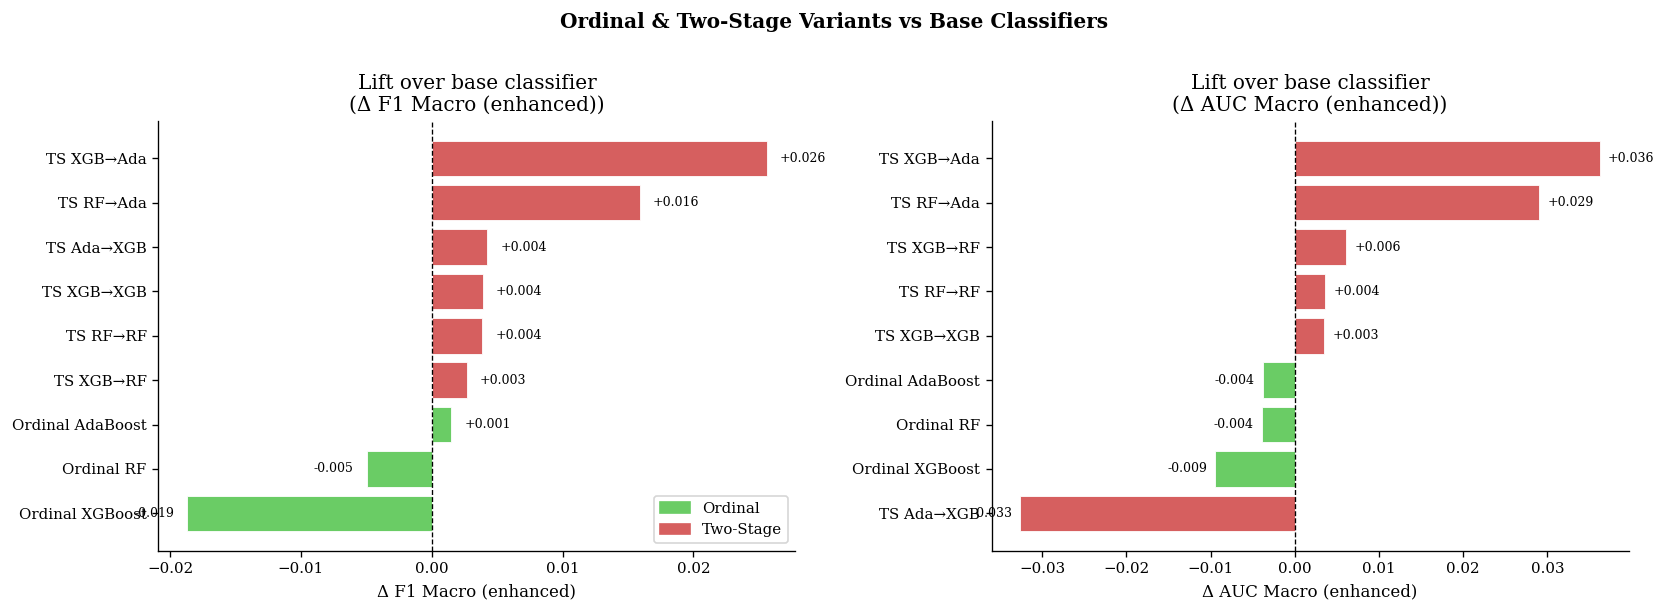

✓ Saved fig_ordinal_twostage_lift.png


In [7]:
def _best_metric(model_name, metric="enhanced_f1_macro"):
    """Return the best (max) metric value for a given model across all strategies."""
    sub = df[df["model"] == model_name]
    if sub.empty:
        return np.nan
    return sub[metric].max()

comparison_rows = []

# ── Ordinal vs base ───────────────────────────────────────────────────────────
for ord_model, base_model in ORDINAL_BASE_MAP.items():
    for metric in ("enhanced_f1_macro", "enhanced_roc_auc_macro"):
        base_val = _best_metric(base_model, metric)
        ord_val  = _best_metric(ord_model,  metric)
        comparison_rows.append({
            "variant":    MODEL_DISPLAY[ord_model],
            "base":       MODEL_DISPLAY[base_model],
            "type":       "Ordinal",
            "metric":     metric.replace("enhanced_","").replace("_macro",""),
            "base_val":   base_val,
            "variant_val":ord_val,
            "delta":      ord_val - base_val,
        })

# ── Two-stage vs base ─────────────────────────────────────────────────────────
for ts_model, base_model in TWO_STAGE_BASE_MAP.items():
    for metric in ("enhanced_f1_macro", "enhanced_roc_auc_macro"):
        base_val = _best_metric(base_model, metric)
        ts_val   = _best_metric(ts_model,   metric)
        comparison_rows.append({
            "variant":    MODEL_DISPLAY[ts_model],
            "base":       MODEL_DISPLAY[base_model],
            "type":       "Two-Stage",
            "metric":     metric.replace("enhanced_","").replace("_macro",""),
            "base_val":   base_val,
            "variant_val":ts_val,
            "delta":      ts_val - base_val,
        })

cmp_df = pd.DataFrame(comparison_rows)

print("=== Ordinal & Two-Stage lift over base classifiers (best config) ===\n")
for metric_short in ("f1", "roc_auc"):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=False)
    label = "F1 macro" if metric_short == "f1" else "AUC macro"
    print(f"--- {label} ---")
    print(sub[["variant","base","type","base_val","variant_val","delta"]]
          .rename(columns={"base_val":"Base","variant_val":"Variant","delta":"Δ"})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()

# ── Bar chart: delta F1 by variant type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric_short, ylabel in zip(
    axes,
    ["f1", "roc_auc"],
    ["Δ F1 Macro (enhanced)", "Δ AUC Macro (enhanced)"]
):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=True)
    colors = [FAMILY_PALETTE["Ordinal"]   if t == "Ordinal"
              else FAMILY_PALETTE["Two-Stage"]
              for t in sub["type"]]
    bars = ax.barh(sub["variant"], sub["delta"], color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(ylabel)
    ax.set_title(f"Lift over base classifier\n({ylabel})")
    for bar, val in zip(bars, sub["delta"]):
        x = bar.get_width()
        ax.text(x + 0.001 * (1 if x >= 0 else -1),
                bar.get_y() + bar.get_height() / 2,
                f"{val:+.3f}", va="center",
                ha="left" if x >= 0 else "right", fontsize=7.5)

legend_patches = [
    mpatches.Patch(color=FAMILY_PALETTE["Ordinal"],   label="Ordinal"),
    mpatches.Patch(color=FAMILY_PALETTE["Two-Stage"], label="Two-Stage"),
]
axes[0].legend(handles=legend_patches, loc="lower right")
plt.suptitle("Ordinal & Two-Stage Variants vs Base Classifiers", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_ordinal_twostage_lift.png")
plt.show()
print(f"✓ Saved fig_ordinal_twostage_lift.png")

## Section 6 — F1 and AUC Bar Charts per Balance Strategy

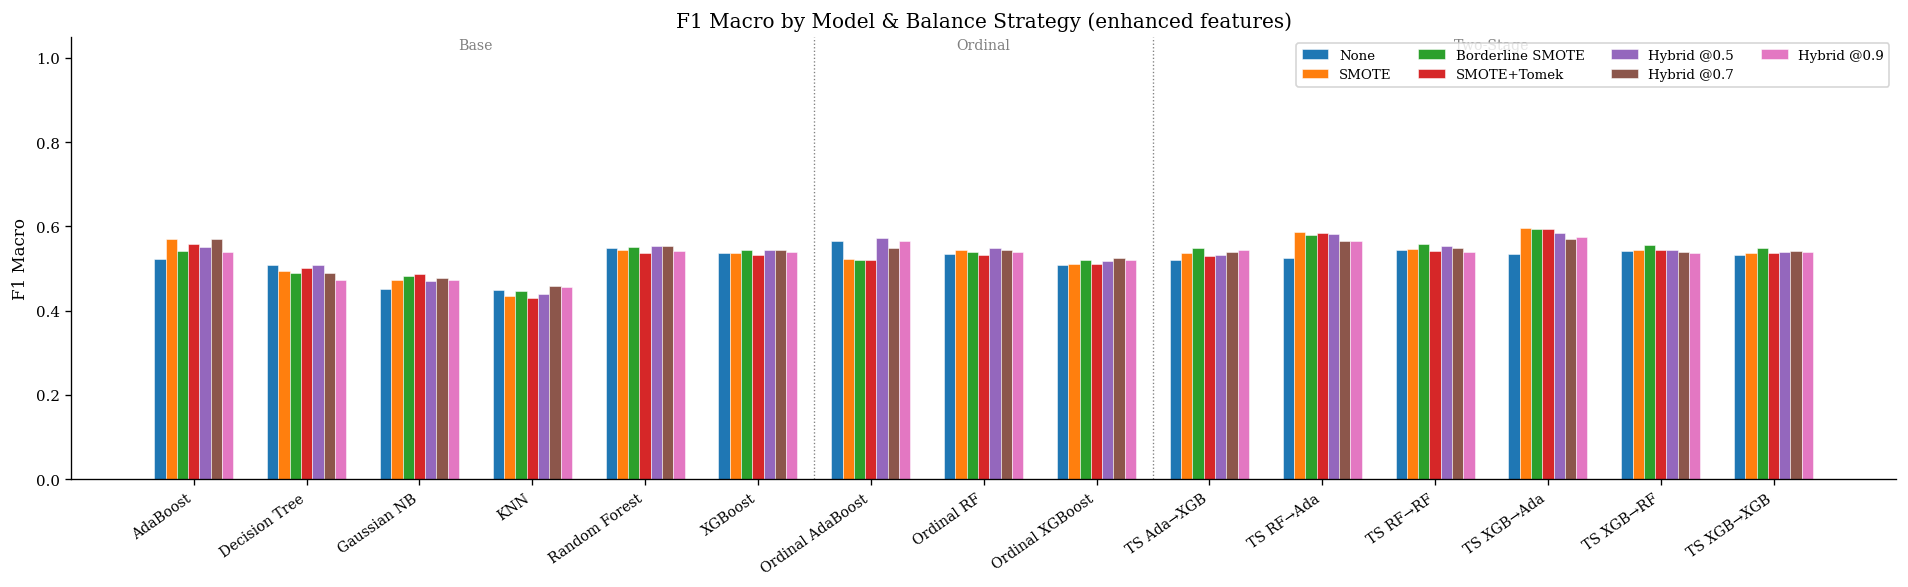

✓ Saved fig_f1_by_strategy.png


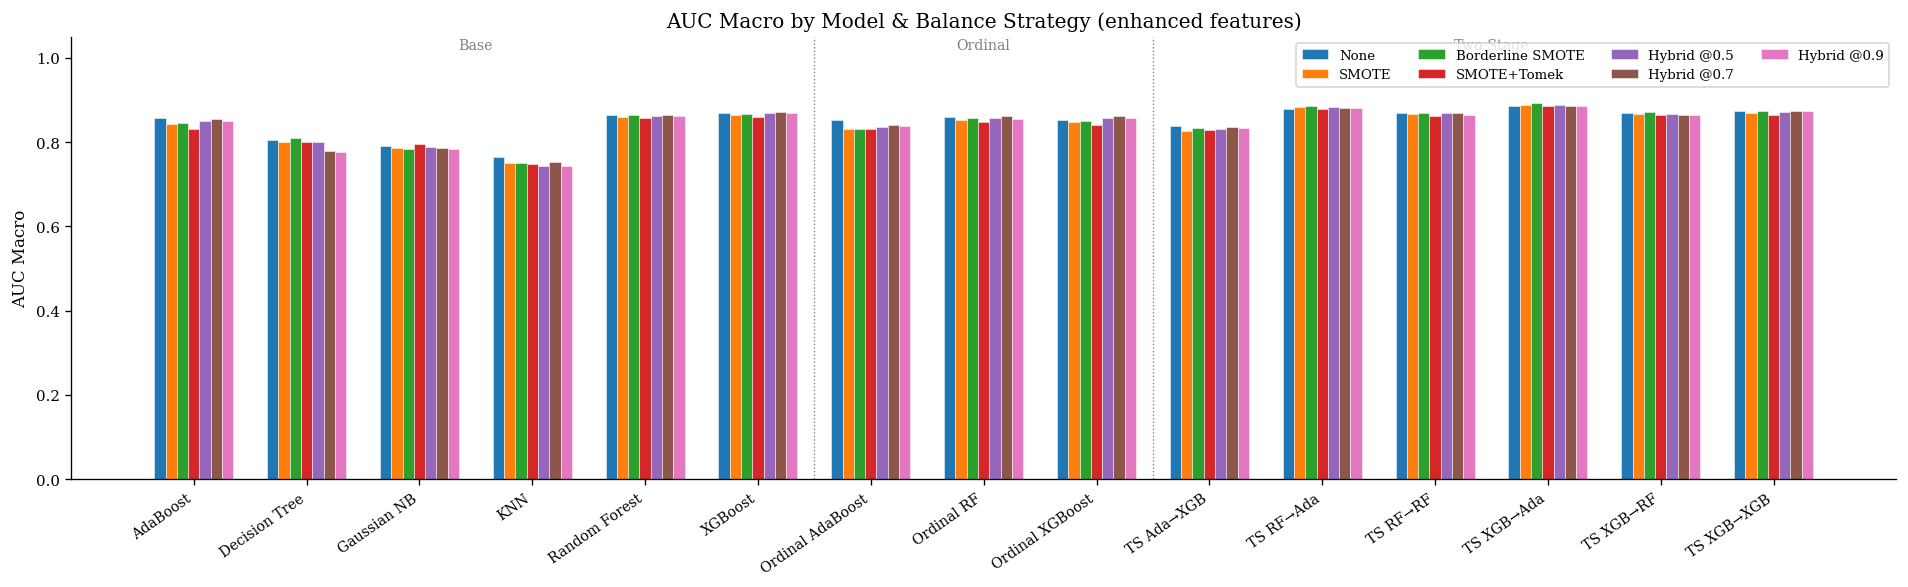

✓ Saved fig_auc_by_strategy.png


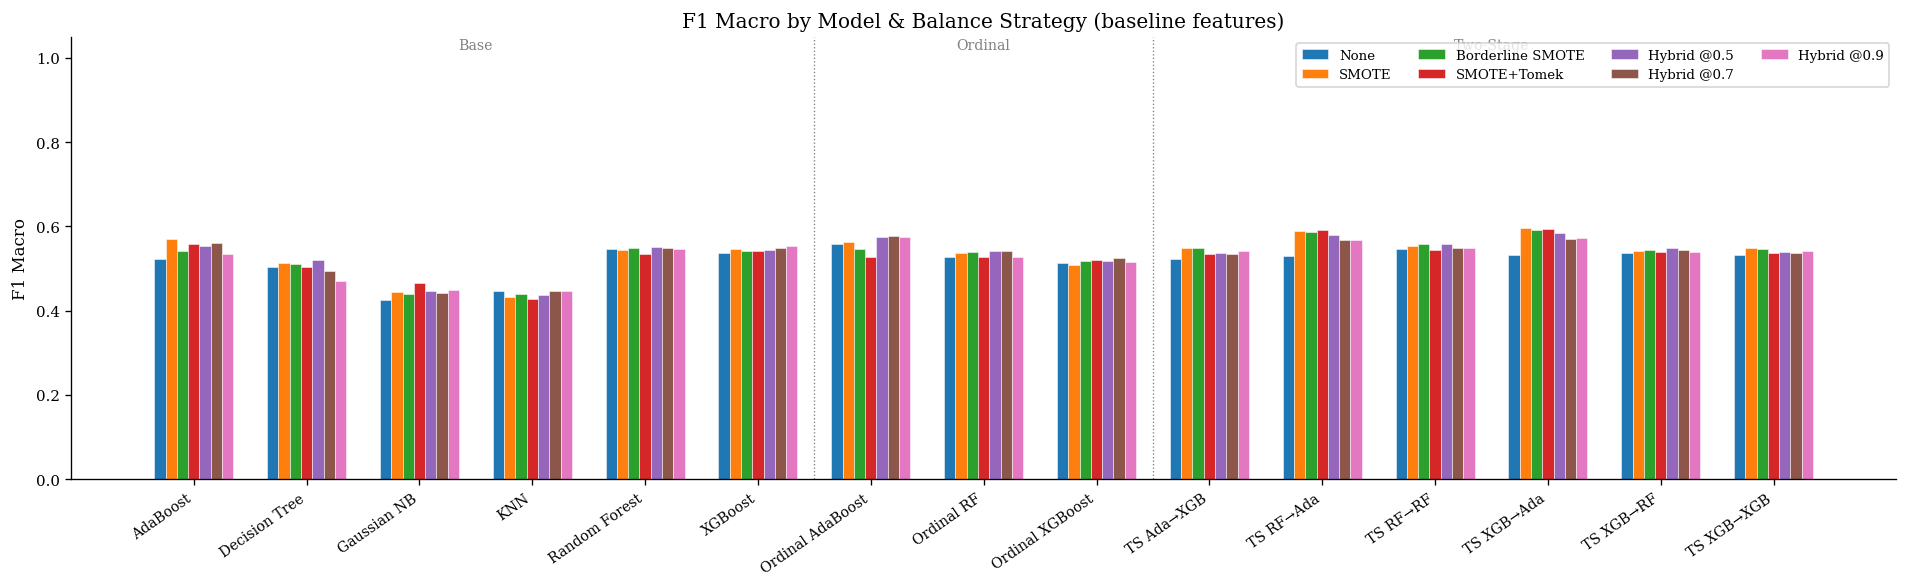

✓ Saved fig_f1_baseline_by_strategy.png


In [8]:
# For each model type: best F1 per strategy (max across param sets)
agg = (
    df.groupby(["model", "strategy_label"])[
        ["enhanced_f1_macro", "enhanced_roc_auc_macro",
         "baseline_f1_macro", "baseline_roc_auc_macro"]
    ]
    .max()
    .reset_index()
)

def _plot_metric_bar(metric_col, ylabel, title_suffix, fname):
    """Grouped bar chart: model × strategy, for one metric."""
    n_models    = len(ALL_MODELS)
    n_strategies = len(STRATEGY_ORDER)
    x = np.arange(n_models)
    width = 0.10
    offsets = np.linspace(-(n_strategies - 1) / 2 * width,
                           (n_strategies - 1) / 2 * width,
                           n_strategies)

    fig, ax = plt.subplots(figsize=(16, 5))
    for i, strat in enumerate(STRATEGY_ORDER):
        vals = []
        for m in ALL_MODELS:
            row = agg[(agg["model"] == m) & (agg["strategy_label"] == strat)]
            vals.append(row[metric_col].values[0] if len(row) else np.nan)
        color = STRATEGY_PALETTE[strat]
        ax.bar(x + offsets[i], vals, width, label=STRATEGY_LABELS[strat],
               color=color, edgecolor="white", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in ALL_MODELS],
                        rotation=35, ha="right", fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Model & Balance Strategy ({title_suffix})")
    ax.legend(ncol=4, fontsize=8, loc="upper right")
    ax.set_ylim(0, 1.05)

    # Family separators
    base_end  = len(BASE_MODELS) - 0.5
    ord_end   = base_end + len(ORDINAL_MODELS)
    for xpos in [base_end, ord_end]:
        ax.axvline(xpos, color="gray", linewidth=0.8, linestyle=":")
    ax.text(len(BASE_MODELS)/2 - 0.5, 1.02, "Base", ha="center",
            fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS)/2 - 0.5, 1.02, "Ordinal",
            ha="center", fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS) + len(TWO_STAGE_MODELS)/2 - 0.5, 1.02,
            "Two-Stage", ha="center", fontsize=8.5, color="gray")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname)
    plt.show()
    print(f"✓ Saved {fname}")

_plot_metric_bar("enhanced_f1_macro",      "F1 Macro",  "enhanced features", "fig_f1_by_strategy.png")
_plot_metric_bar("enhanced_roc_auc_macro", "AUC Macro", "enhanced features", "fig_auc_by_strategy.png")
_plot_metric_bar("baseline_f1_macro",      "F1 Macro",  "baseline features", "fig_f1_baseline_by_strategy.png")

## Section 7 — Heatmap: Model × Balance Strategy × Feature Selection

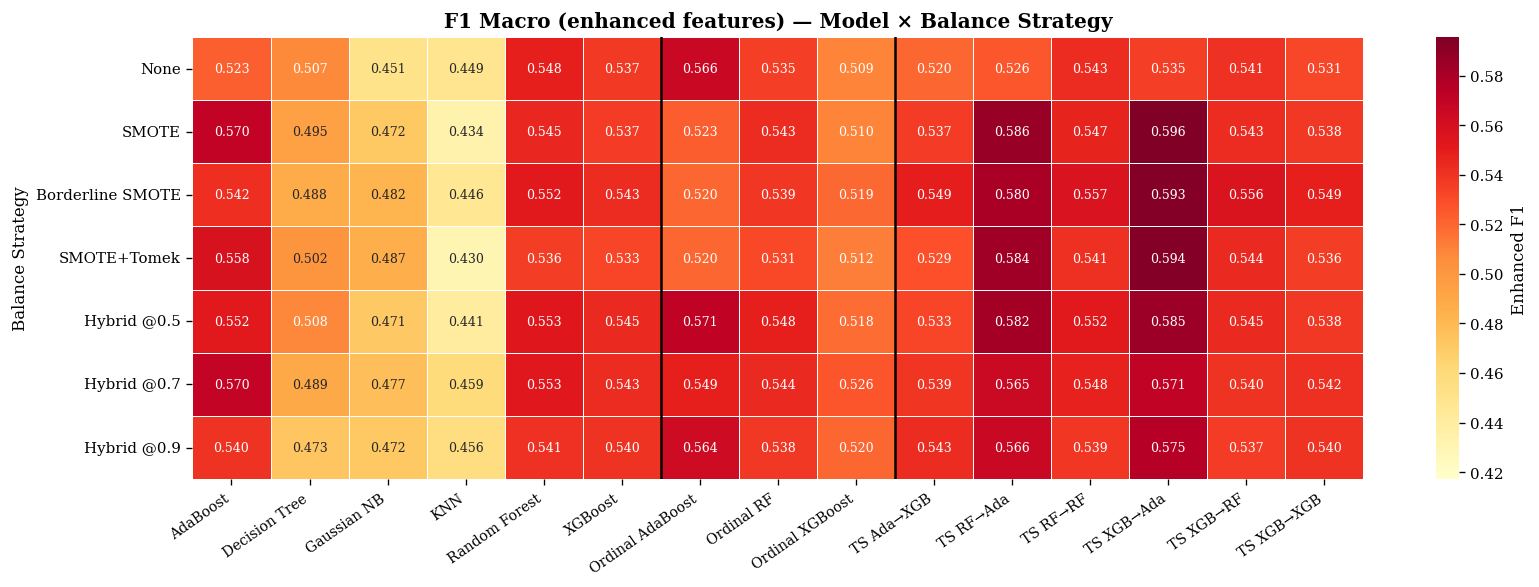

✓ Saved fig_heatmap_f1_enhanced.png


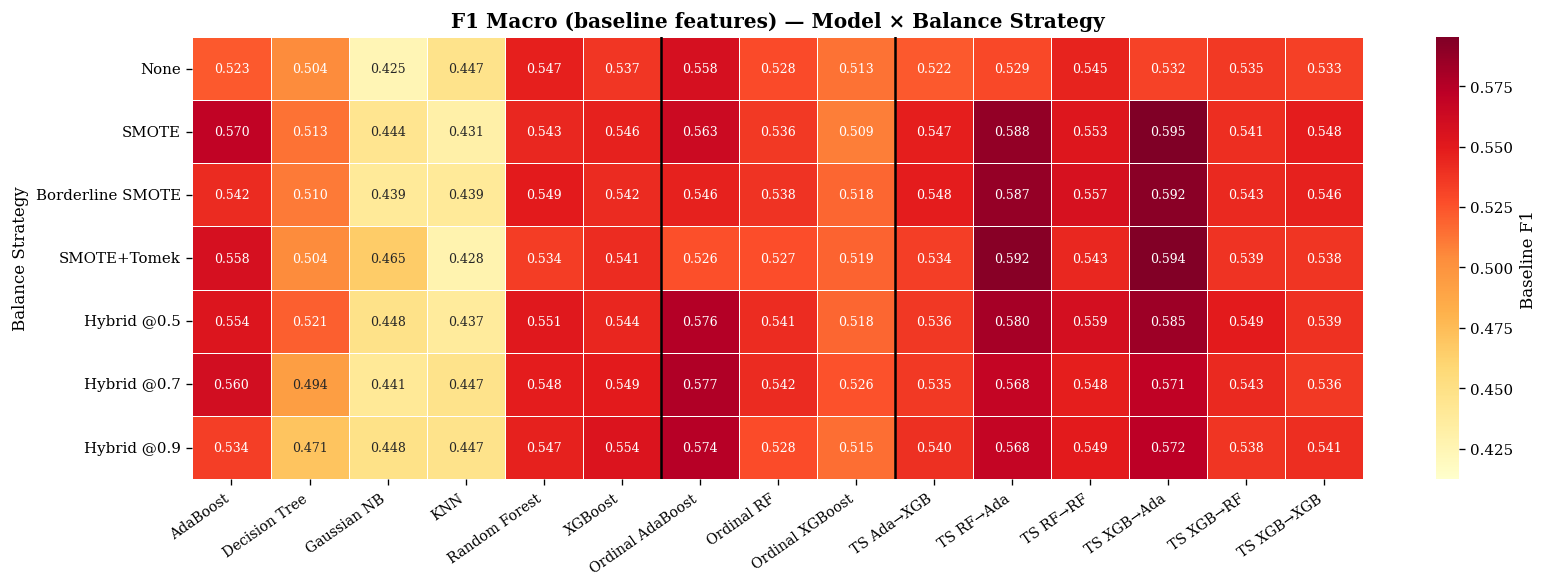

✓ Saved fig_heatmap_f1_baseline.png


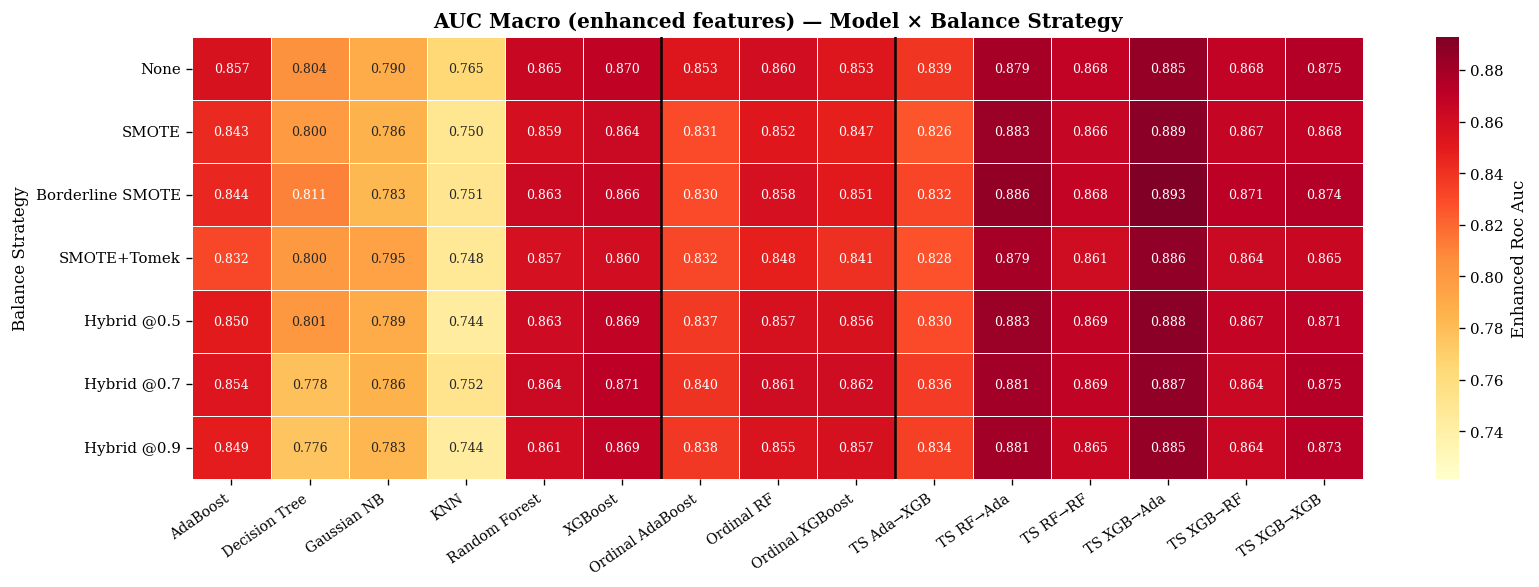

✓ Saved fig_heatmap_auc_enhanced.png


In [9]:
def _heatmap(metric_col, title, fname):
    pivot = (
        agg.pivot_table(
            index   = "strategy_label",
            columns = "model",
            values  = metric_col,
            aggfunc = "max",
        )
        .reindex(index=STRATEGY_ORDER, columns=ALL_MODELS)
        .rename(columns=MODEL_DISPLAY)
        .rename(index=STRATEGY_LABELS)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    im = sns.heatmap(
        pivot,
        ax        = ax,
        annot     = True,
        fmt       = ".3f",
        cmap      = "YlOrRd",
        linewidths= 0.4,
        linecolor = "white",
        vmin      = pivot.values.min() * 0.97,
        annot_kws = {"size": 7.5},
        cbar_kws  = {"label": metric_col.replace("_macro","").replace("_"," ").title()},
    )
    ax.set_title(f"{title}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Balance Strategy")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    # Vertical separators for model families
    ax.axvline(len(BASE_MODELS),                  color="black", linewidth=1.5)
    ax.axvline(len(BASE_MODELS) + len(ORDINAL_MODELS), color="black", linewidth=1.5)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname)
    plt.show()
    print(f"✓ Saved {fname}")

_heatmap("enhanced_f1_macro",      "F1 Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_f1_enhanced.png")
_heatmap("baseline_f1_macro",      "F1 Macro (baseline features) — Model × Balance Strategy",
         "fig_heatmap_f1_baseline.png")
_heatmap("enhanced_roc_auc_macro", "AUC Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_auc_enhanced.png")

## Section 8 — Confusion Matrices for Top-3 Models

=== Top-3 experiments (confusion matrices will be plotted) ===
    id model_display    strategy_label  enhanced_f1_macro  enhanced_roc_auc_macro
1  751    TS XGB→Ada             smote           0.595546                0.888580
2  879    TS XGB→Ada       smote_tomek           0.593582                0.883014
3  817    TS XGB→Ada  borderline_smote           0.593471                0.892786


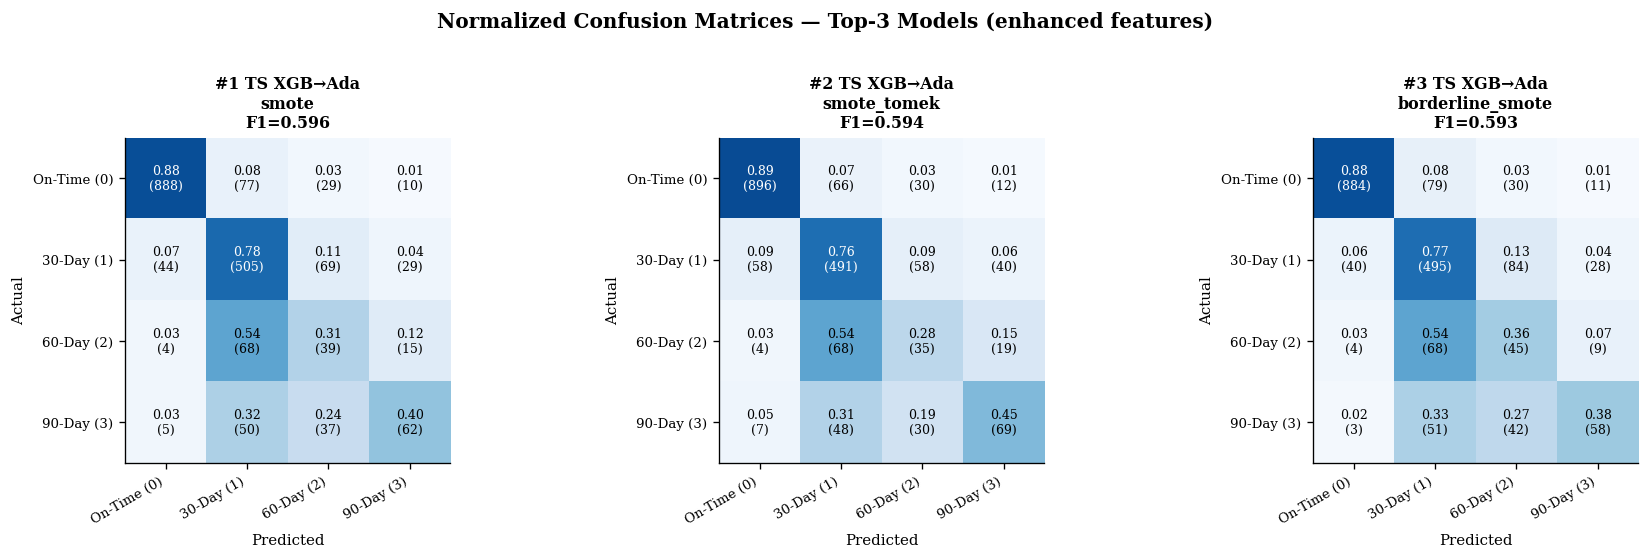

✓ Saved fig_confusion_matrices_top3.png


In [10]:
# ── Identify top-3 experiments by enhanced F1 ────────────────────────────────
top3 = (
    df.sort_values("enhanced_f1_macro", ascending=False)
      .head(3)
      [["id", "model_display", "strategy_label",
        "enhanced_f1_macro", "enhanced_roc_auc_macro"]]
      .reset_index(drop=True)
)
top3.index += 1
print("=== Top-3 experiments (confusion matrices will be plotted) ===")
print(top3.to_string())

# ── Load confusion matrix blobs for these experiments ────────────────────────
top3_ids = top3["id"].tolist()
placeholders = ",".join(["?"] * len(top3_ids))
cm_query = (
    f"SELECT experiment_id, phase, data FROM charts "
    f"WHERE chart_type='confusion_matrix' AND phase='enhanced' "
    f"AND experiment_id IN ({placeholders})"
)
cm_rows = pd.read_sql(cm_query, conn, params=top3_ids)

def _plot_cm(matrix_raw, title, ax):
    cm = np.array(matrix_raw, dtype=float)
    n = cm.shape[0]
    total = cm.sum()
    # Normalize by true row (row-wise recall)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight="bold")
    for i in range(n):
        for j in range(n):
            pct = cm_norm[i, j]
            count = int(cm[i, j])
            color = "white" if pct > 0.55 else "black"
            ax.text(j, i, f"{pct:.2f}\n({count})", ha="center", va="center",
                    color=color, fontsize=7.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax_idx, (_, row) in enumerate(top3.iterrows()):
    exp_id = row["id"]
    cm_row = cm_rows[cm_rows["experiment_id"] == exp_id]
    if cm_row.empty:
        axes[ax_idx].text(0.5, 0.5, "No data", ha="center", va="center")
        continue
    matrix = json.loads(cm_row.iloc[0]["data"])
    label = f"#{ax_idx+1} {row['model_display']}\n{row['strategy_label']}\nF1={row['enhanced_f1_macro']:.3f}"
    _plot_cm(matrix, label, axes[ax_idx])

plt.suptitle("Normalized Confusion Matrices — Top-3 Models (enhanced features)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_confusion_matrices_top3.png")
plt.show()
print("✓ Saved fig_confusion_matrices_top3.png")

## Section 9 — ROC Curves for Top Models

=== Top-5 by enhanced AUC (ROC curves will be plotted) ===
    id model_display    strategy_label  enhanced_roc_auc_macro
1  817    TS XGB→Ada  borderline_smote                0.892786
2  811    TS XGB→Ada  borderline_smote                0.890007
3  818    TS XGB→Ada  borderline_smote                0.889694
4  814    TS XGB→Ada  borderline_smote                0.889468
5  816    TS XGB→Ada  borderline_smote                0.889467


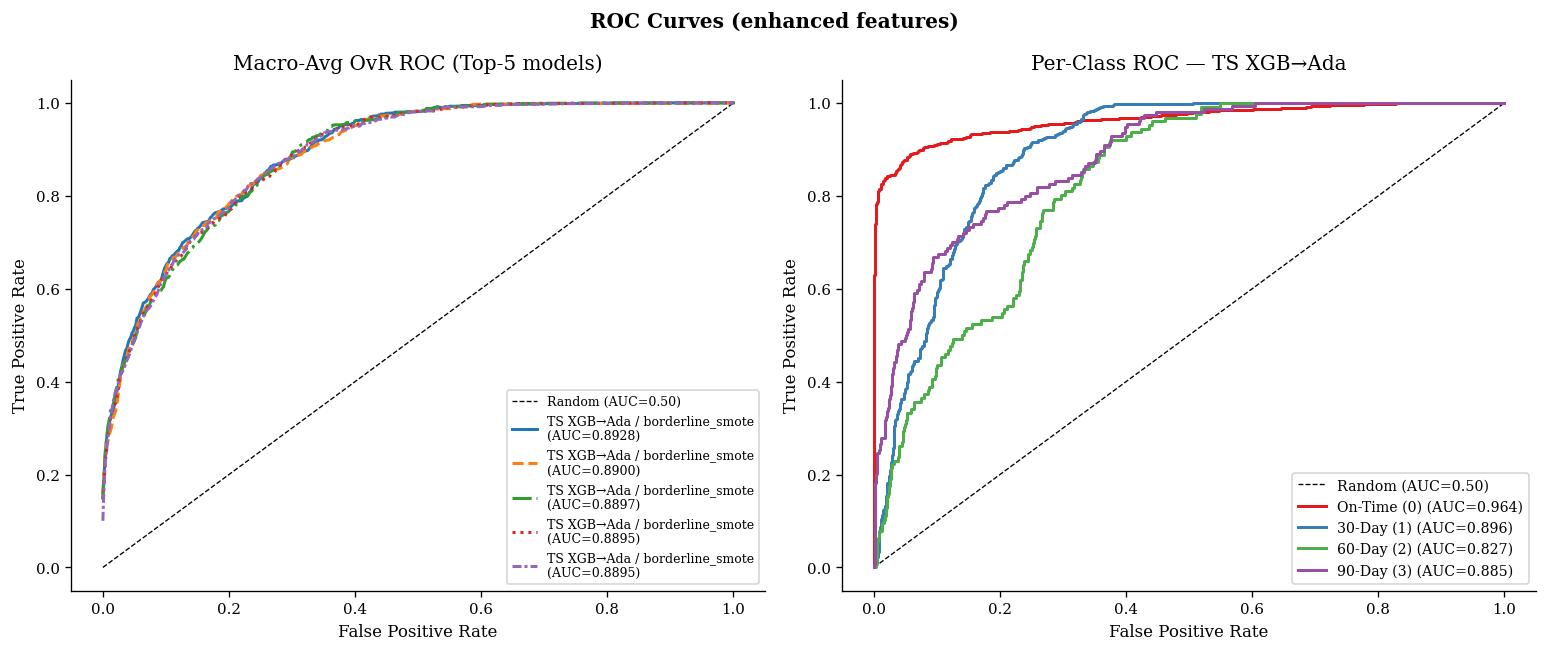

✓ Saved fig_roc_curves.png


In [11]:
# ── Top-5 models by AUC for ROC plot ─────────────────────────────────────────
top5_auc = (
    df.sort_values("enhanced_roc_auc_macro", ascending=False)
      .head(5)[["id", "model_display", "strategy_label", "enhanced_roc_auc_macro"]]
      .reset_index(drop=True)
)
top5_auc.index += 1
print("=== Top-5 by enhanced AUC (ROC curves will be plotted) ===")
print(top5_auc.to_string())

top5_ids = top5_auc["id"].tolist()
ph = ",".join(["?"] * len(top5_ids))
roc_rows = pd.read_sql(
    f"SELECT experiment_id, data FROM charts "
    f"WHERE chart_type='roc_curve' AND phase='enhanced' AND experiment_id IN ({ph})",
    conn, params=top5_ids,
)

# ── Macro-averaged ROC: average TPR over uniform FPR grid ────────────────────
FPR_GRID = np.linspace(0, 1, 500)
LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
LINE_COLORS = sns.color_palette("tab10", 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax in axes:
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random (AUC=0.50)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

# Left: macro OvR for each top-5 model
for idx, (_, row_info) in enumerate(top5_auc.iterrows()):
    exp_id = row_info["id"]
    roc_row = roc_rows[roc_rows["experiment_id"] == exp_id]
    if roc_row.empty:
        continue
    roc_data = json.loads(roc_row.iloc[0]["data"])   # {class_idx: {fpr, tpr, auc}}
    tpr_interps = []
    for cls_key in sorted(roc_data.keys(), key=int):
        cls_data = roc_data[cls_key]
        fpr_arr = np.array(cls_data["fpr"])
        tpr_arr = np.array(cls_data["tpr"])
        tpr_interps.append(np.interp(FPR_GRID, fpr_arr, tpr_arr))
    macro_tpr = np.mean(tpr_interps, axis=0)
    macro_auc = row_info["enhanced_roc_auc_macro"]
    label = f"{row_info['model_display']} / {row_info['strategy_label']}\n(AUC={macro_auc:.4f})"
    axes[0].plot(FPR_GRID, macro_tpr,
                 linestyle=LINE_STYLES[idx], color=LINE_COLORS[idx],
                 linewidth=1.8, label=label)

axes[0].legend(fontsize=7.5, loc="lower right")
axes[0].set_title("Macro-Avg OvR ROC (Top-5 models)")

# Right: per-class ROC for the single best model
best_id = top5_auc.loc[1, "id"]
roc_row = roc_rows[roc_rows["experiment_id"] == best_id]
if not roc_row.empty:
    roc_data = json.loads(roc_row.iloc[0]["data"])
    cls_colors = sns.color_palette("Set1", 4)
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_key = str(cls_idx)
        if cls_key not in roc_data:
            continue
        cls_d = roc_data[cls_key]
        fpr_arr = np.array(cls_d["fpr"])
        tpr_arr = np.array(cls_d["tpr"])
        cls_auc = cls_d.get("auc", float(np.trapezoid(tpr_arr, fpr_arr)))
        axes[1].plot(fpr_arr, tpr_arr, color=cls_colors[cls_idx],
                     linewidth=1.8, label=f"{cls_name} (AUC={cls_auc:.3f})")
    axes[1].legend(fontsize=8.5, loc="lower right")
    axes[1].set_title(f"Per-Class ROC — {top5_auc.loc[1,'model_display']}")

plt.suptitle("ROC Curves (enhanced features)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_roc_curves.png")
plt.show()
print("✓ Saved fig_roc_curves.png")

## Section 10 — Feature Importance Plots

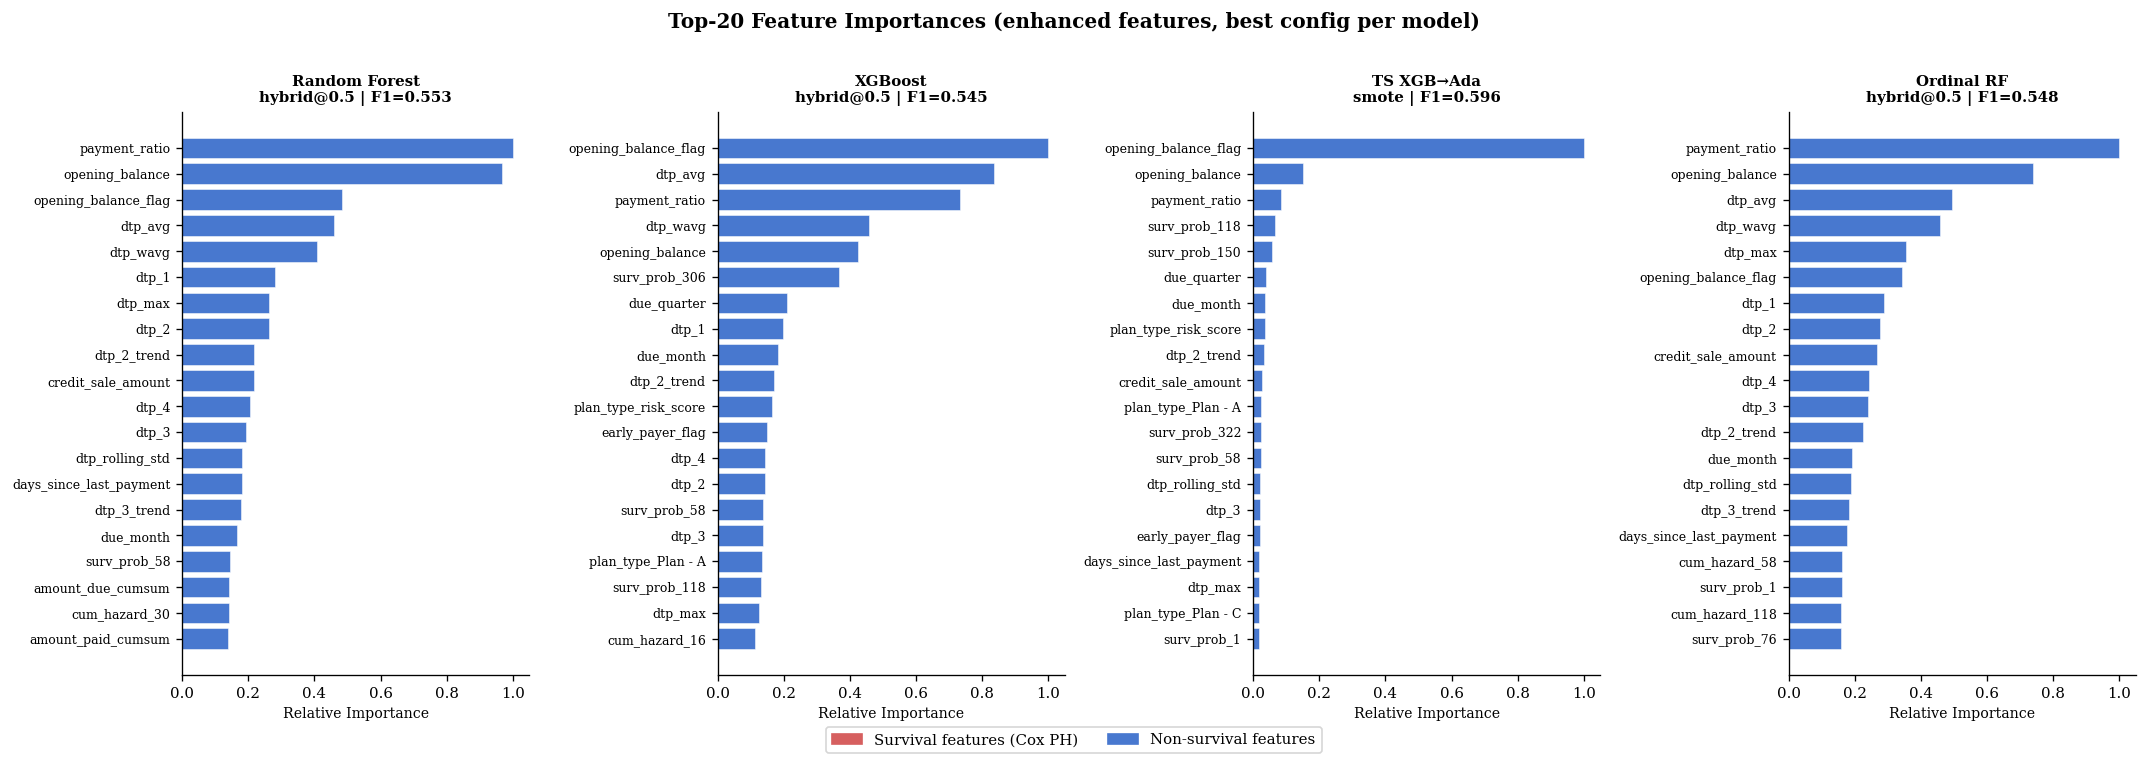

✓ Saved fig_feature_importance.png


In [12]:
# Survival features generated by the Cox PH pipeline
SURVIVAL_FEATURES = {
    "survival_prob", "hazard", "expected_survival", "partial_hazard", "log_partial_hazard",
    "survival_at_30", "survival_at_60", "survival_at_90",
}

def _get_best_exp_id(model_name):
    """Return experiment_id of the best configuration for a model (max enhanced F1)."""
    sub = df[df["model"] == model_name].sort_values("enhanced_f1_macro", ascending=False)
    return int(sub.iloc[0]["id"]) if not sub.empty else None

FEAT_MODELS = ["random_forest", "xgboost", "two_stage_xgb_ada", "ordinal_random_forest"]

def _load_feature_weights(exp_id, phase="enhanced"):
    """Return sorted list of (feature, weight) from features table."""
    row = feat_df[(feat_df["experiment_id"] == exp_id) & (feat_df["phase"] == phase)]
    if row.empty:
        return []
    weights_raw = row.iloc[0]["weights_json"]
    if not weights_raw:
        return []
    weights = json.loads(weights_raw)
    # Multi-stage format: {"stage_1": {feat: w}, "stage_2": {...}}
    if isinstance(weights, dict) and all(isinstance(v, dict) for v in weights.values()):
        # Use stage_1 (first-stage classifier importance)
        weights = weights.get("stage_1", list(weights.values())[0])
    if isinstance(weights, dict):
        return sorted(weights.items(), key=lambda x: x[1], reverse=True)
    return []

fig, axes = plt.subplots(1, len(FEAT_MODELS), figsize=(18, 6))

for ax, model_name in zip(axes, FEAT_MODELS):
    exp_id = _get_best_exp_id(model_name)
    if exp_id is None:
        ax.text(0.5, 0.5, f"No data for\n{model_name}", ha="center", va="center")
        continue

    feat_weights = _load_feature_weights(exp_id)[:20]   # top 20
    if not feat_weights:
        ax.text(0.5, 0.5, "No feature data", ha="center", va="center")
        continue

    features, weights = zip(*feat_weights)
    weights = np.array(weights, dtype=float)
    # Normalize to [0, 1]
    if weights.max() > 0:
        weights = weights / weights.max()

    colors = ["#D65F5F" if f in SURVIVAL_FEATURES else "#4878CF" for f in features]

    ax.barh(range(len(features)), weights, color=colors, edgecolor="white", linewidth=0.3)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel("Relative Importance", fontsize=8.5)

    best_strat = df[df["id"] == exp_id]["strategy_label"].values[0]
    best_f1    = df[df["id"] == exp_id]["enhanced_f1_macro"].values[0]
    ax.set_title(f"{MODEL_DISPLAY.get(model_name, model_name)}\n"
                 f"{best_strat} | F1={best_f1:.3f}", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#D65F5F", label="Survival features (Cox PH)"),
    mpatches.Patch(color="#4878CF", label="Non-survival features"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Top-20 Feature Importances (enhanced features, best config per model)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_feature_importance.png", bbox_inches="tight")
plt.show()
print("✓ Saved fig_feature_importance.png")

## Section 11 — McNemar's Statistical Significance Testing

McNemar's test requires **paired per-sample predictions** from two classifiers on the **same test set**.  
The DB stores aggregate metrics and chart blobs — not raw prediction arrays.

**Approach used here:**
1. Identify the top model pairs from Section 3 rankings
2. Re-run those specific configurations through the ML pipeline to capture `y_pred` arrays
3. Construct the 2×2 contingency table (correct/incorrect)
4. Apply McNemar's test using `statsmodels`

> For two classifiers A and B on the same test set of N samples:
> - **n₀₁** = A correct & B incorrect  
> - **n₁₀** = A incorrect & B correct  
> - McNemar statistic = (|n₀₁ − n₁₀| − 1)² / (n₀₁ + n₁₀) (with continuity correction)

In [13]:
import sys, os, json, types
sys.path.insert(0, os.path.abspath("."))

# Determine top comparison pairs
top_overall   = df.sort_values("enhanced_f1_macro", ascending=False).iloc[0]
best_two_stage_row = (
    df[df["family"] == "Two-Stage"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)
best_single_row = (
    df[df["family"] == "Base"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)
best_ordinal_row = (
    df[df["family"] == "Ordinal"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)

MCNEMAR_PAIRS = [
    ("Best Two-Stage",   best_two_stage_row),
    ("Best Single-Stage",best_single_row),
    ("Best Ordinal",     best_ordinal_row),
]

print("=== Pairs identified for McNemar's test ===")
for label, row in MCNEMAR_PAIRS:
    print(f"  {label:<22} | {row['model_display']:<25} | "
          f"Strategy: {row['strategy_label']:<18} | "
          f"F1={row['enhanced_f1_macro']:.4f}  AUC={row['enhanced_roc_auc_macro']:.4f}")
    print(f"  {'':22}   exp_id={int(row['id'])}, param_hash={row['param_hash']}")
    print()

=== Pairs identified for McNemar's test ===
  Best Two-Stage         | TS XGB→Ada                | Strategy: smote              | F1=0.5955  AUC=0.8886
                           exp_id=751, param_hash=8c29d5

  Best Single-Stage      | AdaBoost                  | Strategy: smote              | F1=0.5700  AUC=0.8327
                           exp_id=84, param_hash=a74d55

  Best Ordinal           | Ordinal AdaBoost          | Strategy: hybrid@0.5         | F1=0.5714  AUC=0.8228
                           exp_id=421, param_hash=0b0656



In [14]:
import warnings
from datetime import datetime
from types import SimpleNamespace
import pandas as pd

from machine_learning.utils.data.data_preparation import DataPreparer
from machine_learning.utils.training.run_models_parallel import SurvivalExperimentRunner
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor
from utils.data_loaders.read_settings_json import read_settings_json

# ── 1. Load settings (mirrors Machine Learning.ipynb cell 32) ─────────────────
settings  = read_settings_json(file_path="settings.json")
obs_end   = datetime.strptime(settings["Training"]["observation_end"], "%Y/%m/%d")

args_mcn = SimpleNamespace(
    observation_end = obs_end,
    target_feature  = settings["Training"]["target_feature"],
    test_size       = float(settings["Training"]["test_size"]),
    parameters_dir  = settings["Training"]["MODEL_PARAMETERS"],
    time_points     = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450],
)

# ── 2. Load raw data ───────────────────────────────────────────────────────────
df_revenues_mcn  = pd.read_excel(r"database\revenues_pseudonymized.xlsx")
df_enrollees_mcn = pd.read_excel(r"database\enrollees_pseudonymized.xlsx")

cs_mcn = CreditSalesProcessor(
    df_revenues_mcn, df_enrollees_mcn, args_mcn,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True,
)
df_credit_sales_mcn = cs_mcn.show_data()

# ── 3. Separate classifier vs survival DataFrames ─────────────────────────────
_surv_cols     = ["days_elapsed_until_fully_paid", "censor"]
_non_surv_cols = ["due_date", "dtp_bracket"]

df_data_mcn      = df_credit_sales_mcn[df_credit_sales_mcn["censor"] == 1].copy()
df_data_mcn.drop(columns=_surv_cols, inplace=True)
df_data_surv_mcn = df_credit_sales_mcn.drop(columns=_non_surv_cols)

# ── 4. Cox best parameters + time-points (same as original run) ───────────────
best_surv_parameters_mcn = {"alpha": 0.05, "l1_ratio": 0.5}   # C-index = 0.7817

from machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from machine_learning.utils.features.get_slope_time_points import get_slope_timepoints

T_mcn = adjust_payment_period(df_data_surv_mcn["days_elapsed_until_fully_paid"])
E_mcn = df_data_surv_mcn["censor"]
args_mcn.time_points = get_slope_timepoints(T_mcn, E_mcn, n_points=9)

print(f"df_data_mcn      : {df_data_mcn.shape}")
print(f"df_data_surv_mcn : {df_data_surv_mcn.shape}")
print(f"time_points      : {args_mcn.time_points}")


Single due date records:   10377
Multiple due date records: 289
Excluded school years [2016, 2017, 2018]: removed 234 rows, 10177 remaining.
Dropped 3650 invoices with missing DTP values. Remaining: 6527
df_data_mcn      : (6435, 29)
df_data_surv_mcn : (6527, 29)
time_points      : [1, 16, 30, 58, 76, 118, 150, 306, 322]


In [15]:
import ast
import warnings

from machine_learning.utils.training.run_models_parallel import (
    SurvivalExperimentRunner, _build_pipelines_fn,
    _ORDINAL_ESTIMATOR_MAP, _TWO_STAGE_ESTIMATOR_PAIRS,
)
from machine_learning.models.ordinal_classifier import OrdinalPipeline
from machine_learning.models.two_stage_classifier import TwoStagePipeline
import machine_learning as ml_models


def _parse_param_string(model_name, param_str):
    """
    Parse the DB 'parameters' column string back to a dict for _build_pipelines_fn.
    The DB stores strings with surrounding double-quotes, e.g.:
      '"stage1={...}, stage2={...}"'   (two-stage models)
      '"[(\'key\', val), ...]"'         (all other models)
    """
    # Strip surrounding double- or single-quotes added by DB storage
    param_str = param_str.strip('"').strip("'")

    if model_name in _TWO_STAGE_ESTIMATOR_PAIRS:
        # Stored as: "stage1={...}, stage2={...}"
        s2_marker = ", stage2="
        idx = param_str.index(s2_marker)
        stage1 = ast.literal_eval(param_str[len("stage1="):idx])
        stage2 = ast.literal_eval(param_str[idx + len(s2_marker):])
        # Remove 'device' key to avoid GPU-only issues during re-run
        stage1.pop("device", None)
        stage2.pop("device", None)
        return {"stage1": stage1, "stage2": stage2}
    else:
        # Stored as: "[('key', val), ('key2', val2), ...]"
        pairs = ast.literal_eval(param_str)
        d = dict(pairs)
        d.pop("device", None)
        return d


_MODEL_CLASS_MAP = {
    "ada_boost":            ml_models.AdaBoostPipeline,
    "decision_tree":        ml_models.DecisionTreePipeline,
    "gaussian_naive_bayes": ml_models.GaussianNaiveBayesPipeline,
    "knn":                  ml_models.KNearestNeighborPipeline,
    "random_forest":        ml_models.RandomForestPipeline,
    "xgboost":              ml_models.XGBoostPipeline,
}
for _m in _ORDINAL_ESTIMATOR_MAP:
    _MODEL_CLASS_MAP[_m] = OrdinalPipeline
for _m in _TWO_STAGE_ESTIMATOR_PAIRS:
    _MODEL_CLASS_MAP[_m] = TwoStagePipeline


def get_predictions_for_config(model_name, balance_strategy, undersample_threshold,
                                parameters_str, phase="enhanced"):
    """
    Re-run one experiment configuration and return (y_true, y_pred) on the test set.
    Mirrors the SurvivalExperimentRunner pipeline exactly.

    Parameters
    ----------
    model_name            : str   e.g. "two_stage_xgb_ada"
    balance_strategy      : str   e.g. "smote"
    undersample_threshold : float or None
    parameters_str        : str   The DB 'parameters' column string for this experiment
    phase                 : "enhanced" (default, uses survival features) or "baseline"
    """
    PipelineClass = _MODEL_CLASS_MAP.get(model_name)
    if PipelineClass is None:
        raise ValueError(f"Unknown model: {model_name!r}")

    params = _parse_param_string(model_name, str(parameters_str))

    runner = SurvivalExperimentRunner(
        df_data            = df_data_mcn,
        df_data_surv       = df_data_surv_mcn,
        models             = {model_name: PipelineClass},
        balance_strategies = [balance_strategy],
        args               = args_mcn,
        best_parameters    = best_surv_parameters_mcn,
        thresholds         = [undersample_threshold] if undersample_threshold is not None else None,
        n_jobs             = 1,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dataset = runner.prepare_dataset(balance_strategy, undersample_threshold)

    X_train, X_test, y_train, y_test, X_surv_train, X_surv_test = dataset

    pipeline_baseline, pipeline_enhanced = _build_pipelines_fn(
        model_name, PipelineClass, params,
        X_train, X_test, X_surv_train, X_surv_test,
        y_train, y_test,
        args_mcn, use_lda=False, lda_mode="append",
    )

    pipeline = pipeline_enhanced if phase == "enhanced" else pipeline_baseline
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipeline.initialize_model().fit(use_feature_selection=True)

    y_pred = np.array(pipeline.predict(pipeline.X_test))
    y_true = np.array(pipeline.y_test)
    return y_true, y_pred


print("✓ _parse_param_string defined (strips outer quotes, removes 'device' key)")
print("✓ _MODEL_CLASS_MAP defined")
print("✓ get_predictions_for_config defined")


✓ _parse_param_string defined (strips outer quotes, removes 'device' key)
✓ _MODEL_CLASS_MAP defined
✓ get_predictions_for_config defined


In [17]:
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar


def run_mcnemar_pair(label_a, row_a, label_b, row_b):
    """
    Run McNemar's test comparing two model configurations.
    Collects predictions by re-running each configuration on the same test split.
    Data is loaded from globals: df_data_mcn, df_data_surv_mcn, args_mcn.
    """
    print(f"\n--- McNemar's test: {label_a} vs {label_b} ---")

    results = {}
    for label, row in [(label_a, row_a), (label_b, row_b)]:
        display = MODEL_DISPLAY.get(str(row["model"]), str(row["model"]))
        strategy = str(row["balance_strategy"])
        print(f"  Running {label}: {display} / {strategy} ...")
        try:
            thr = row.get("undersample_threshold")
            thr = float(thr) if (thr is not None and str(thr) not in ("None", "nan", "")) else None
            y_true, y_pred = get_predictions_for_config(
                model_name             = str(row["model"]),
                balance_strategy       = str(row["balance_strategy"]),
                undersample_threshold  = thr,
                parameters_str         = str(row.get("parameters", "")),
                phase                  = "enhanced",
            )
            results[label] = (np.array(y_true), np.array(y_pred))
            acc = np.mean(results[label][0] == results[label][1])
            print(f"    accuracy={acc:.4f}  n={len(y_true)}")
        except Exception as e:
            import traceback
            print(f"    ⚠ Failed: {e}")
            traceback.print_exc()
            return None

    y_true_a, y_pred_a = results[label_a]
    y_true_b, y_pred_b = results[label_b]

    if len(y_true_a) != len(y_true_b):
        print(f"  ⚠ Test set sizes differ ({len(y_true_a)} vs {len(y_true_b)}) — cannot pair")
        return None

    correct_a = (y_pred_a == y_true_a)
    correct_b = (y_pred_b == y_true_b)

    n11 = int(np.sum( correct_a &  correct_b))
    n10 = int(np.sum( correct_a & ~correct_b))
    n01 = int(np.sum(~correct_a &  correct_b))
    n00 = int(np.sum(~correct_a & ~correct_b))

    table = np.array([[n11, n10], [n01, n00]])
    print(f"  Contingency table (correct / incorrect):")
    print(f"    Both correct       : {n11}")
    print(f"    A correct, B wrong : {n10}")
    print(f"    A wrong, B correct : {n01}")
    print(f"    Both wrong         : {n00}")
    print(f"    Discordant pairs   : {n01 + n10}")

    if (n01 + n10) == 0:
        print(f"  McNemar's: no discordant pairs — models are identical on this test set")
        return {"pair": f"{label_a} vs {label_b}", "chi2": 0.0, "pval": 1.0,
                "significant": False, "n01": n01, "n10": n10, "n11": n11, "n00": n00}

    result = sm_mcnemar(table, exact=False, correction=True)
    sig = result.pvalue < 0.05
    print(f"  χ²  = {result.statistic:.4f}")
    print(f"  p   = {result.pvalue:.4f}  {'← SIGNIFICANT (p<0.05)' if sig else '(not significant)'}")

    return {
        "pair":        f"{label_a} vs {label_b}",
        "chi2":        result.statistic,
        "pval":        result.pvalue,
        "significant": sig,
        "n01":         n01,
        "n10":         n10,
        "n11":         n11,
        "n00":         n00,
    }


print("✓ run_mcnemar_pair defined")


✓ run_mcnemar_pair defined


In [18]:
# ── Run the two priority comparisons from plan1.md ───────────────────────────
mcnemar_results = []

# Pair 1: Best two-stage vs best single-stage
r1 = run_mcnemar_pair(
    "Best Two-Stage",    best_two_stage_row,
    "Best Single-Stage", best_single_row,
)
if r1:
    mcnemar_results.append(r1)

# Pair 2: Best ordinal vs best base (its corresponding single-stage model)
_ordinal_base_model = ORDINAL_BASE_MAP.get(str(best_ordinal_row["model"]),
                                            str(best_ordinal_row["model"]))
_best_ordinal_base = (
    df[df["model"] == _ordinal_base_model]
    .sort_values("enhanced_f1_macro", ascending=False)
    .iloc[0]
)
r2 = run_mcnemar_pair(
    "Best Ordinal",                      best_ordinal_row,
    f"Base of Ordinal ({_ordinal_base_model})", _best_ordinal_base,
)
if r2:
    mcnemar_results.append(r2)

# ── Summary table ─────────────────────────────────────────────────────────────
if mcnemar_results:
    print("\n=== McNemar's Test Summary ===")
    mcn_df = pd.DataFrame(mcnemar_results)
    mcn_df["sig"] = mcn_df["significant"].map({True: "* p<0.05", False: "n.s."})
    display_cols = ["pair", "n01", "n10", "chi2", "pval", "sig"]
    print(mcn_df[display_cols]
          .rename(columns={"n01": "n₀₁", "n10": "n₁₀", "chi2": "χ²",
                           "pval": "p-value", "sig": "Sig."})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("No McNemar's results computed.")



--- McNemar's test: Best Two-Stage vs Best Single-Stage ---
  Running Best Two-Stage: TS XGB→Ada / smote ...
[dataset] Preparing: smote ...
[dataset]   Generating survival features ...
[dataset]   Done (26s)
    accuracy=0.7706  n=1931
  Running Best Single-Stage: AdaBoost / smote ...
[dataset] Preparing: smote ...
[dataset]   Generating survival features ...
[dataset]   Done (11s)
    accuracy=0.7359  n=1931
  Contingency table (correct / incorrect):
    Both correct       : 1381
    A correct, B wrong : 107
    A wrong, B correct : 40
    Both wrong         : 403
    Discordant pairs   : 147
  χ²  = 29.6327
  p   = 0.0000  ← SIGNIFICANT (p<0.05)

--- McNemar's test: Best Ordinal vs Base of Ordinal (ada_boost) ---
  Running Best Ordinal: Ordinal AdaBoost / hybrid ...
[dataset] Preparing: hybrid@0.5 ...
[dataset]   Generating survival features ...
[dataset]   Done (8s)
    accuracy=0.7359  n=1931
  Running Base of Ordinal (ada_boost): AdaBoost / smote ...
[dataset] Preparing: smote ..

## Final Summary

In [19]:
import os

print("=" * 60)
print("RESULTS ANALYSIS COMPLETE")
print("=" * 60)

# List generated figures
print(f"\nFigures saved to: {OUTPUT_DIR.resolve()}")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f.name:<45} ({size_kb:>6.1f} KB)")

print("\nKey findings:")
print(f"  Best overall F1  : {df['enhanced_f1_macro'].max():.4f}")
print(f"  Best overall AUC : {df['enhanced_roc_auc_macro'].max():.4f}")
print(f"  Best model       : {df.loc[df['enhanced_f1_macro'].idxmax(), 'model_display']}")
print(f"  Best strategy    : {df.loc[df['enhanced_f1_macro'].idxmax(), 'strategy_label']}")
print()
print("  Top family comparison:")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub = df[df["family"] == fam]
    f1  = sub["enhanced_f1_macro"].max()
    auc = sub["enhanced_roc_auc_macro"].max()
    best_m = sub.loc[sub["enhanced_f1_macro"].idxmax(), "model_display"]
    print(f"    {fam:<12} best F1={f1:.4f}  AUC={auc:.4f}  ({best_m})")

# Close DB connection
conn.close()
print("\n✓ DB connection closed")

RESULTS ANALYSIS COMPLETE

Figures saved to: D:\Developer\Projects\THESIS-Utilizing-ML-to-Solve-the-IPPP\docs\202616APRIL-RESULTSGRAPHS
  fig_auc_by_strategy.png                       ( 241.4 KB)
  fig_confusion_matrices_top3.png               ( 278.1 KB)
  fig_f1_baseline_by_strategy.png               ( 238.6 KB)
  fig_f1_by_strategy.png                        ( 237.6 KB)
  fig_feature_importance.png                    ( 352.1 KB)
  fig_heatmap_auc_enhanced.png                  ( 466.7 KB)
  fig_heatmap_f1_baseline.png                   ( 437.0 KB)
  fig_heatmap_f1_enhanced.png                   ( 433.7 KB)
  fig_ordinal_twostage_lift.png                 ( 228.1 KB)
  fig_roc_curves.png                            ( 378.9 KB)

Key findings:
  Best overall F1  : 0.5955
  Best overall AUC : 0.8928
  Best model       : TS XGB→Ada
  Best strategy    : smote

  Top family comparison:
    Base         best F1=0.5700  AUC=0.8712  (AdaBoost)
    Ordinal      best F1=0.5714  AUC=0.8618  (Ordina